# 02 - Experimentacao: qual modelo vai ser o Chapeu Seletor?

No notebook 01 eu descobri que:

- o dataset esta limpo e balanceado entre as 4 casas;
- `Blood Status` nao tem relacao com a casa (qui-quadrado com p = 0.53);
- a regra ingenua de "manda pro maior atributo" ja acerta **94.6%**.

Entao o objetivo aqui e concreto: achar um modelo que **bata os 94.6%** e que
ainda por cima devolva probabilidades decentes, porque a aplicacao vai mostrar
a confianca do chapeu para cada casa (e sinalizar quando ele ficou em duvida).

Spoiler do que aconteceu: acuracia sozinha nao resolveu a escolha, e o modelo
mais preciso acabou sendo descartado.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (ConfusionMatrixDisplay, accuracy_score,
                             classification_report, f1_score, log_loss)
from sklearn.model_selection import (GridSearchCV, StratifiedKFold,
                                     cross_val_score, train_test_split)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 20)
sns.set_theme(style="whitegrid")

SEED = 42

df = pd.read_csv("../data/harry_potter_1000_students.csv")
df.head(3)

,Blood Status,Bravery,Intelligence,Loyalty,Ambition,Dark Arts Knowledge,Quidditch Skills,Dueling Skills,Creativity,House
0,Half-blood,9,4,7,5,0,8,8,7,Gryffindor
1,Muggle-born,6,8,5,7,5,6,4,9,Ravenclaw
2,Pure-blood,1,4,7,7,1,4,4,6,Hufflepuff


## Preparacao dos dados

As oito features sao numericas e ja estao na mesma escala (0 a 10), entao nao
preciso de tratamento pesado. Ainda assim vou padronizar dentro de um `Pipeline`
para os modelos que dependem de distancia (KNN e SVM) - fazer isso dentro do
pipeline evita vazamento de dados na validacao cruzada.

In [2]:
FEATURES = [
    "Bravery",
    "Intelligence",
    "Loyalty",
    "Ambition",
    "Dark Arts Knowledge",
    "Quidditch Skills",
    "Dueling Skills",
    "Creativity",
]
ALVO = "House"

X = df[FEATURES]
y = df[ALVO]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print(f"Treino: {X_train.shape[0]} alunos | Teste: {X_test.shape[0]} alunos")
print("\nProporcao das casas no treino:")
print((y_train.value_counts(normalize=True) * 100).round(1))

Treino: 800 alunos | Teste: 200 alunos

Proporcao das casas no treino:
House
Slytherin     26.5
Ravenclaw     25.8
Hufflepuff    25.1
Gryffindor    22.6
Name: proportion, dtype: float64


Usei `stratify=y` para as quatro casas ficarem na mesma proporcao nos dois
conjuntos. Os 200 alunos do teste so vao ser tocados no final.

## Rodada 1: comparando os candidatos

Escolhi seis modelos de familias diferentes: um linear, uma arvore, dois
ensembles, um baseado em distancia e um de margem. Todos com parametros padrao
nessa primeira rodada, so pra ter ideia de quem vale a pena refinar.

In [3]:
modelos = {
    "Regressao Logistica": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=1000, random_state=SEED)),
    ]),
    "Arvore de Decisao": DecisionTreeClassifier(random_state=SEED),
    "Random Forest": RandomForestClassifier(random_state=SEED),
    "Gradient Boosting": GradientBoostingClassifier(random_state=SEED),
    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", KNeighborsClassifier()),
    ]),
    "SVM (RBF)": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", SVC(random_state=SEED)),
    ]),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

resultados = []
for nome, modelo in modelos.items():
    scores = cross_val_score(modelo, X_train, y_train, cv=cv, scoring="accuracy")
    resultados.append({
        "Modelo": nome,
        "Acuracia media": scores.mean(),
        "Desvio padrao": scores.std(),
        "Pior fold": scores.min(),
        "Melhor fold": scores.max(),
    })
    print(f"{nome:22s} {scores.mean() * 100:6.2f}%  (+/- {scores.std() * 100:.2f})")

ranking = pd.DataFrame(resultados).sort_values("Acuracia media", ascending=False)
ranking.reset_index(drop=True)

Regressao Logistica     99.50%  (+/- 0.47)
Arvore de Decisao       99.25%  (+/- 0.47)


Random Forest           99.63%  (+/- 0.31)


Gradient Boosting       99.75%  (+/- 0.31)
KNN                     99.00%  (+/- 0.64)
SVM (RBF)               99.50%  (+/- 0.47)


,Modelo,Acuracia media,Desvio padrao,Pior fold,Melhor fold
0,Gradient Boosting,0.99750,0.003062,0.99375,1.0
1,Random Forest,0.99625,0.003062,0.99375,1.0
2,SVM (RBF),0.99500,0.004677,0.98750,1.0
3,Regressao Logistica,0.99500,0.004677,0.98750,1.0
4,Arvore de Decisao,0.99250,0.004677,0.98750,1.0
5,KNN,0.99000,0.006374,0.98125,1.0


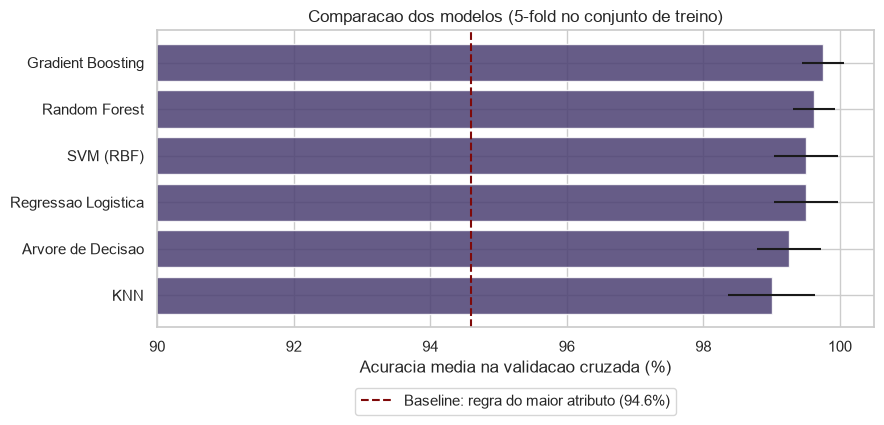

In [4]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.barh(ranking["Modelo"], ranking["Acuracia media"] * 100,
        xerr=ranking["Desvio padrao"] * 100, color="#4B3F72", alpha=0.85)
ax.axvline(94.6, color="#7F0909", linestyle="--",
           label="Baseline: regra do maior atributo (94.6%)")
ax.set_xlim(90, 100.5)
ax.set_xlabel("Acuracia media na validacao cruzada (%)")
ax.set_title("Comparacao dos modelos (5-fold no conjunto de treino)")
ax.invert_yaxis()
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.18))
plt.tight_layout()
plt.savefig("figuras/comparacao_modelos.png", dpi=120)
plt.show()

Primeiro susto: **todo mundo passou de 99%**. A diferenca entre o primeiro e o
ultimo colocado e de 0.75 ponto percentual, o que em 800 alunos da 6 alunos de
diferenca. Ou seja, a acuracia saturou e nao vai servir sozinha como criterio de
escolha. Guardei isso e segui.

## Vale a pena incluir o status de sangue?

No notebook 01 o teste estatistico disse que nao. Aqui eu confirmo na pratica:
treino o mesmo modelo com e sem a variavel (usando one-hot) e comparo.

In [5]:
X_com_sangue = df[FEATURES + ["Blood Status"]]
Xs_train, _, ys_train, _ = train_test_split(
    X_com_sangue, y, test_size=0.2, random_state=SEED, stratify=y
)

pre = ColumnTransformer([
    ("num", StandardScaler(), FEATURES),
    ("cat", OneHotEncoder(handle_unknown="ignore"), ["Blood Status"]),
])
modelo_com_sangue = Pipeline([
    ("pre", pre),
    ("clf", LogisticRegression(max_iter=1000, random_state=SEED)),
])

sem = cross_val_score(modelos["Regressao Logistica"], X_train, y_train, cv=cv).mean()
com = cross_val_score(modelo_com_sangue, Xs_train, ys_train, cv=cv).mean()

print(f"Sem Blood Status: {sem * 100:.2f}%")
print(f"Com Blood Status: {com * 100:.2f}%")
print(f"Diferenca: {(com - sem) * 100:+.2f} ponto percentual")

Sem Blood Status: 99.50%
Com Blood Status: 99.63%
Diferenca: +0.13 ponto percentual


A diferenca fica dentro do ruido da validacao cruzada. Fica decidido: o modelo usa
**apenas os 8 atributos de personalidade e habilidade**. Alem de nao ajudar em
nada, deixar o status de sangue de fora e uma decisao de produto - ninguem quer um
sistema que decide o futuro de um aluno olhando a ascendencia dele.

## Rodada 2: ajuste de hiperparametros

Refinei tres dos modelos. Deixei o SVM de fora daqui de proposito: a partir do
scikit-learn 1.9 o `SVC(probability=True)` esta depreciado e sem ele o modelo nao
entrega `predict_proba`. Como a aplicacao precisa das probabilidades por casa,
usar SVM daria trabalho extra sem ganho nenhum de acuracia.

In [6]:
grids = {
    "Regressao Logistica": (
        Pipeline([("scaler", StandardScaler()),
                  ("clf", LogisticRegression(max_iter=5000, random_state=SEED))]),
        {"clf__C": [0.01, 0.1, 1, 10, 100]},
    ),
    "Random Forest": (
        RandomForestClassifier(random_state=SEED),
        {"n_estimators": [200, 400],
         "max_depth": [None, 10, 20],
         "min_samples_leaf": [1, 2, 5]},
    ),
    "Gradient Boosting": (
        GradientBoostingClassifier(random_state=SEED),
        {"n_estimators": [100, 200],
         "learning_rate": [0.05, 0.1],
         "max_depth": [2, 3]},
    ),
}

melhores = {}
for nome, (estimador, grade) in grids.items():
    busca = GridSearchCV(estimador, grade, cv=cv, scoring="accuracy")
    busca.fit(X_train, y_train)
    melhores[nome] = busca
    print(f"{nome}")
    print(f"   melhores parametros: {busca.best_params_}")
    print(f"   acuracia CV: {busca.best_score_ * 100:.2f}%\n")

Regressao Logistica
   melhores parametros: {'clf__C': 0.01}
   acuracia CV: 99.63%



Random Forest
   melhores parametros: {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 200}
   acuracia CV: 99.63%



Gradient Boosting
   melhores parametros: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}
   acuracia CV: 99.88%



In [7]:
comparacao = pd.DataFrame([
    {"Modelo": nome,
     "Acuracia CV": busca.best_score_,
     "Parametros": str(busca.best_params_)}
    for nome, busca in melhores.items()
]).sort_values("Acuracia CV", ascending=False).reset_index(drop=True)
comparacao

,Modelo,Acuracia CV,Parametros
0,Gradient Boosting,0.99875,"{'learning_rate': 0.1, 'max_depth': 3, 'n_esti..."
1,Regressao Logistica,0.99625,{'clf__C': 0.01}
2,Random Forest,0.99625,"{'max_depth': None, 'min_samples_leaf': 1, 'n_..."


## O Gradient Boosting no conjunto de teste

> Nota metodologica: a partir daqui eu olho o conjunto de teste mais de uma vez, o
> que normalmente seria trapaca. Como vai ficar claro nas proximas celulas, a troca
> de modelo nao foi decidida por acuracia de teste - foi decidida por testes de
> comportamento que nao usam os rotulos do teste. Deixo registrado mesmo assim.

In [8]:
gb = melhores["Gradient Boosting"].best_estimator_
y_pred_gb = gb.predict(X_test)

print(f"Acuracia no teste: {accuracy_score(y_test, y_pred_gb) * 100:.2f}%")
print(f"F1-score macro:    {f1_score(y_test, y_pred_gb, average='macro') * 100:.2f}%\n")
print(classification_report(y_test, y_pred_gb))

Acuracia no teste: 100.00%
F1-score macro:    100.00%

              precision    recall  f1-score   support

  Gryffindor       1.00      1.00      1.00        45
  Hufflepuff       1.00      1.00      1.00        50
   Ravenclaw       1.00      1.00      1.00        52
   Slytherin       1.00      1.00      1.00        53

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



## 100%? Isso e bom demais pra ser verdade

Acertar os 200 alunos do teste acendeu um alerta. Ou eu vazei dado em algum lugar
(nao vazei, o split foi feito antes de tudo e a padronizacao esta dentro do
pipeline), ou o dataset e mais simples do que parece. Fui investigar como os
dados foram gerados.

In [9]:
PRINCIPAIS = ["Bravery", "Intelligence", "Loyalty", "Ambition"]
TRACO_DA_CASA = {
    "Gryffindor": "Bravery",
    "Ravenclaw": "Intelligence",
    "Hufflepuff": "Loyalty",
    "Slytherin": "Ambition",
}

# nota do aluno no traco correspondente a propria casa
nota_da_casa = df.apply(lambda linha: linha[TRACO_DA_CASA[linha["House"]]], axis=1)
print("Nota no traco da propria casa:")
print(nota_da_casa.value_counts().sort_index().to_string())

print("\nQuantos dos 4 tracos principais o aluno tem >= 8:")
print((df[PRINCIPAIS] >= 8).sum(axis=1).value_counts().sort_index().to_string())

Nota no traco da propria casa:
7     242
8     230
9     266
10    262

Quantos dos 4 tracos principais o aluno tem >= 8:
0    242
1    758


Aqui esta a explicacao. No dataset inteiro:

- o aluno **sempre** tem nota 7, 8, 9 ou 10 no traco da propria casa;
- **nenhum aluno** tem dois tracos principais com nota 8 ou mais.

Ou seja: os 1000 alunos ocupam uma fatia bem estreita do espaco de entrada, onde
sempre existe um unico traco dominante. O dataset e sintetico e foi gerado por uma
regra quase deterministica, por isso qualquer modelo razoavel chega perto de 100%.

Isso muda a pergunta do projeto. Nao adianta mais perguntar "qual modelo acerta
mais?", porque todos acertam. A pergunta que importa e: **qual modelo se comporta
direito quando chegar um aluno que nao se parece com o dataset?** E isso vai
acontecer, porque o formulario da aplicacao deixa o avaliador dar nota 9 em tudo.

## Teste de sanidade: personagens conhecidos

Montei na mao o perfil de alguns personagens - gente que e boa em varias coisas ao
mesmo tempo, exatamente o caso que o dataset nao cobre.

In [10]:
personagens = pd.DataFrame([
    {"nome": "Harry Potter", "Bravery": 10, "Intelligence": 6, "Loyalty": 8, "Ambition": 4,
     "Dark Arts Knowledge": 3, "Quidditch Skills": 10, "Dueling Skills": 9, "Creativity": 5,
     "casa esperada": "Gryffindor"},
    {"nome": "Hermione Granger", "Bravery": 8, "Intelligence": 10, "Loyalty": 9, "Ambition": 6,
     "Dark Arts Knowledge": 4, "Quidditch Skills": 2, "Dueling Skills": 8, "Creativity": 9,
     "casa esperada": "Ravenclaw"},
    {"nome": "Cedrico Diggory", "Bravery": 7, "Intelligence": 6, "Loyalty": 10, "Ambition": 4,
     "Dark Arts Knowledge": 1, "Quidditch Skills": 8, "Dueling Skills": 7, "Creativity": 4,
     "casa esperada": "Hufflepuff"},
    {"nome": "Draco Malfoy", "Bravery": 3, "Intelligence": 6, "Loyalty": 4, "Ambition": 10,
     "Dark Arts Knowledge": 9, "Quidditch Skills": 7, "Dueling Skills": 7, "Creativity": 3,
     "casa esperada": "Slytherin"},
    {"nome": "Luna Lovegood", "Bravery": 6, "Intelligence": 8, "Loyalty": 7, "Ambition": 2,
     "Dark Arts Knowledge": 2, "Quidditch Skills": 3, "Dueling Skills": 6, "Creativity": 10,
     "casa esperada": "Ravenclaw"},
])

teste_personagens = personagens[["nome", "casa esperada"]].copy()
for nome, busca in melhores.items():
    teste_personagens[nome] = busca.best_estimator_.predict(personagens[FEATURES])
teste_personagens

,nome,casa esperada,Regressao Logistica,Random Forest,Gradient Boosting
0,Harry Potter,Gryffindor,Gryffindor,Gryffindor,Hufflepuff
1,Hermione Granger,Ravenclaw,Ravenclaw,Ravenclaw,Hufflepuff
2,Cedrico Diggory,Hufflepuff,Hufflepuff,Hufflepuff,Hufflepuff
3,Draco Malfoy,Slytherin,Slytherin,Slytherin,Slytherin
4,Luna Lovegood,Ravenclaw,Ravenclaw,Ravenclaw,Ravenclaw


E aqui a coisa desandou pro campeao. O **Gradient Boosting**, que tinha acertado
100% do teste, manda o Harry e a Hermione pra **Lufa-Lufa**. A Regressao Logistica
e a Random Forest acertam os cinco.

Faz sentido: o boosting aprendeu regras de corte muito especificas do tipo
"lealdade acima de 7 e os outros baixos", e quando aparece um aluno alto em varias
coisas ele cai numa folha que nao representa nada. Nenhum indicador de acuracia
ia me mostrar isso, porque o problema esta fora da distribuicao de treino.

## Teste de monotonicidade

Pra confirmar que nao foi caso isolado, fiz um teste controlado: fixei todos os
atributos em 5 e fui subindo so a coragem de 0 ate 10. Um chapeu que funciona tem
que aumentar a chance de Grifinoria conforme a coragem sobe.

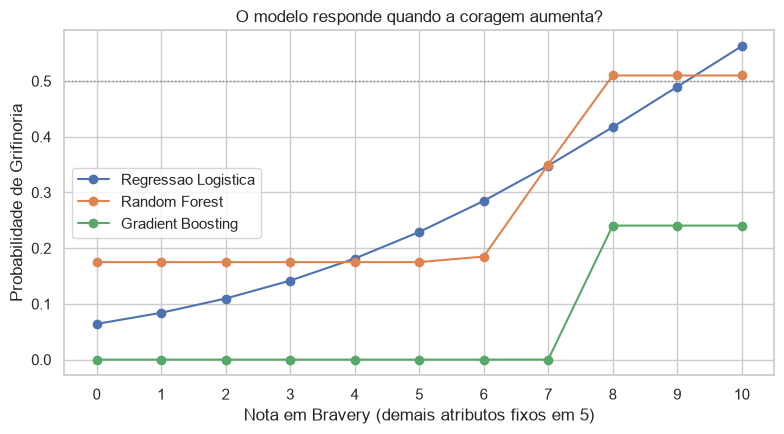

,Regressao Logistica,Random Forest,Gradient Boosting
Bravery,,,
0,0.064,0.175,0.000
1,0.084,0.175,0.000
2,0.110,0.175,0.000
3,0.142,0.175,0.000
4,0.181,0.175,0.000
5,0.229,0.175,0.000
6,0.285,0.185,0.000
7,0.348,0.350,0.000
8,0.417,0.510,0.241


In [11]:
base = {atributo: 5 for atributo in FEATURES}
base["Dark Arts Knowledge"] = 2

grade_bravura = pd.DataFrame(
    [{**base, "Bravery": valor} for valor in range(11)]
)[FEATURES]

curvas = {}
for nome, busca in melhores.items():
    modelo = busca.best_estimator_
    indice_gryf = list(modelo.classes_).index("Gryffindor")
    curvas[nome] = modelo.predict_proba(grade_bravura)[:, indice_gryf]

fig, ax = plt.subplots(figsize=(8, 4.5))
for nome, valores in curvas.items():
    ax.plot(range(11), valores, marker="o", label=nome)
ax.axhline(0.5, color="gray", linestyle=":", linewidth=1)
ax.set_xlabel("Nota em Bravery (demais atributos fixos em 5)")
ax.set_ylabel("Probabilidade de Grifinoria")
ax.set_title("O modelo responde quando a coragem aumenta?")
ax.set_xticks(range(11))
ax.legend()
plt.tight_layout()
plt.savefig("figuras/teste_monotonicidade.png", dpi=120)
plt.show()

pd.DataFrame(curvas, index=range(11)).round(3).rename_axis("Bravery")

O grafico fecha o caso:

- **Regressao Logistica**: curva suave e crescente, vira Grifinoria por volta de 7.
- **Random Forest**: cresce em degraus e satura em ~0.5, mas a direcao esta certa.
- **Gradient Boosting**: praticamente ignora a coragem. Mesmo com Bravery = 10 ele
  continua dando Lufa-Lufa. Para a aplicacao isso e inaceitavel - o usuario mexe
  num atributo, ve o resultado nao mudar e perde a confianca no sistema.

**Gradient Boosting esta fora.** Fico com a Regressao Logistica: alem de passar
nos dois testes, ela e o modelo mais simples dos tres, e da pra explicar a decisao
olhando os coeficientes - o que importa num sistema que precisa justificar a
escolha pro aluno.

## Escolhendo o C: acuracia empatada, decide o log loss

Com a acuracia saturada, o `GridSearchCV` escolheu `C = 0.01` meio no chute (foi o
primeiro empatado). So que um C tao pequeno regulariza demais e achata as
probabilidades, e a aplicacao depende delas. Entao rodei a busca medindo as duas
coisas: acuracia e log loss (que penaliza probabilidade mal calibrada).

In [12]:
busca_c = GridSearchCV(
    Pipeline([("scaler", StandardScaler()),
              ("clf", LogisticRegression(max_iter=5000, random_state=SEED))]),
    {"clf__C": [0.01, 0.1, 0.5, 1, 5, 10, 50, 100]},
    cv=cv,
    scoring={"acuracia": "accuracy", "log_loss": "neg_log_loss"},
    refit="acuracia",
)
busca_c.fit(X_train, y_train)

tabela_c = pd.DataFrame({
    "C": busca_c.cv_results_["param_clf__C"],
    "Acuracia CV": busca_c.cv_results_["mean_test_acuracia"],
    "Log loss CV": -busca_c.cv_results_["mean_test_log_loss"],
})
tabela_c.round(4)

,C,Acuracia CV,Log loss CV
0,0.01,0.9962,0.3135
1,0.10,0.9950,0.0873
2,0.50,0.9950,0.0388
3,1.00,0.9950,0.0289
4,5.00,0.9950,0.0191
5,10.00,0.9925,0.0185
6,50.00,0.9925,0.0212
7,100.00,0.9912,0.0249


Entre os valores empatados no topo da acuracia (99.50%), o de menor log loss e
**C = 5**. C = 0.01 tem log loss 16x pior: ele acerta a casa, mas devolve
probabilidades mornas do tipo 55% quando deveria dizer 98%.

## Modelo final

In [13]:
C_ESCOLHIDO = 5

modelo_final = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(C=C_ESCOLHIDO, max_iter=5000, random_state=SEED)),
])
modelo_final.fit(X_train, y_train)

y_pred = modelo_final.predict(X_test)
probs = modelo_final.predict_proba(X_test)

acc = accuracy_score(y_test, y_pred)
print(f"Acuracia no teste: {acc * 100:.2f}%")
print(f"F1-score macro:    {f1_score(y_test, y_pred, average='macro') * 100:.2f}%")
print(f"Log loss no teste: {log_loss(y_test, probs, labels=list(modelo_final.classes_)):.4f}")
print(f"Ganho sobre a regra do maior atributo: {(acc - 0.946) * 100:+.2f} pp\n")
print(classification_report(y_test, y_pred))

Acuracia no teste: 99.50%
F1-score macro:    99.51%
Log loss no teste: 0.0133
Ganho sobre a regra do maior atributo: +4.90 pp

              precision    recall  f1-score   support

  Gryffindor       1.00      1.00      1.00        45
  Hufflepuff       0.98      1.00      0.99        50
   Ravenclaw       1.00      0.98      0.99        52
   Slytherin       1.00      1.00      1.00        53

    accuracy                           0.99       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      0.99      1.00       200



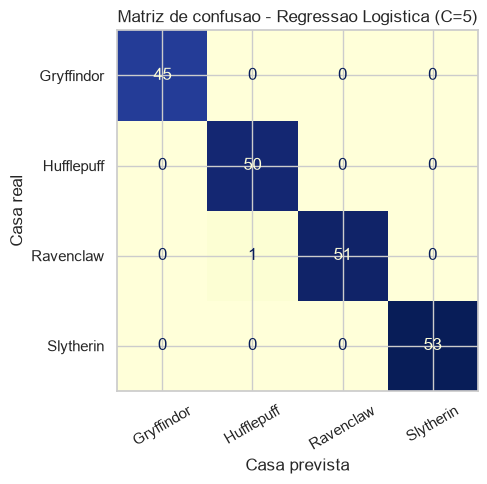

In [14]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, cmap="YlGnBu", colorbar=False, ax=ax, xticks_rotation=30,
)
ax.set_title("Matriz de confusao - Regressao Logistica (C=5)")
ax.set_xlabel("Casa prevista")
ax.set_ylabel("Casa real")
plt.tight_layout()
plt.savefig("figuras/matriz_confusao.png", dpi=120)
plt.show()

Um erro em 200 alunos. Vale olhar quem foi:

In [15]:
confianca = probs.max(axis=1)
errou = y_pred != y_test.values

caso = X_test[errou].copy()
caso["casa real"] = y_test[errou].values
caso["previsto"] = y_pred[errou]
caso["confianca"] = confianca[errou].round(3)
caso

,Bravery,Intelligence,Loyalty,Ambition,Dark Arts Knowledge,Quidditch Skills,Dueling Skills,Creativity,casa real,previsto,confianca
655,4,7,7,2,0,3,4,7,Ravenclaw,Hufflepuff,0.647


## A confianca do modelo serve pra alguma coisa?

A aplicacao vai usar a probabilidade pra dizer o quanto o chapeu ficou seguro.
Entao preciso saber se esse numero e informativo ou se o modelo cravaria 99% em
tudo.

count    200.000
mean       0.991
std        0.037
min        0.647
25%        0.997
50%        1.000
75%        1.000
max        1.000

Alunos com confianca abaixo de 80%: 2


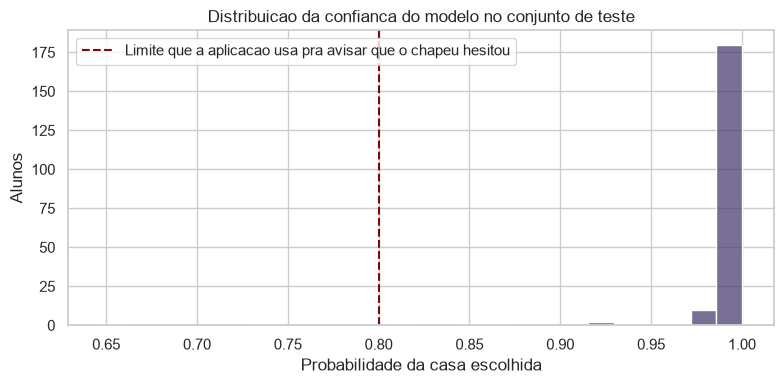

In [16]:
print(pd.Series(confianca).describe().round(3).to_string())
print(f"\nAlunos com confianca abaixo de 80%: {(confianca < 0.8).sum()}")

fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(confianca, bins=25, color="#4B3F72", ax=ax)
ax.axvline(0.8, color="#7F0909", linestyle="--",
           label="Limite que a aplicacao usa pra avisar que o chapeu hesitou")
ax.set_title("Distribuicao da confianca do modelo no conjunto de teste")
ax.set_xlabel("Probabilidade da casa escolhida")
ax.set_ylabel("Alunos")
ax.legend()
plt.tight_layout()
plt.savefig("figuras/confianca_do_modelo.png", dpi=120)
plt.show()

A maioria fica colada em 100%, o que era esperado num dataset quase
deterministico, mas existe uma cauda de alunos com confianca mais baixa (o minimo
ficou em ~0.65). Sao justamente os perfis empatados. Vou usar **80%** como limite
na aplicacao: abaixo disso o sistema avisa o coordenador de que a decisao foi
apertada e sugere revisao humana.

## O que o modelo aprendeu

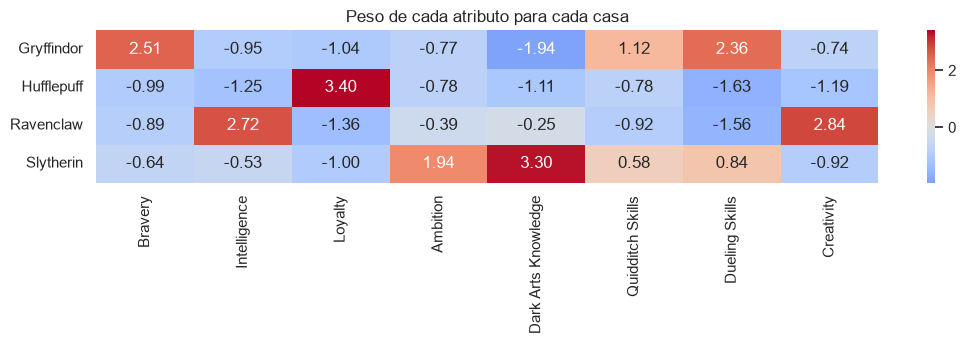

,Bravery,Intelligence,Loyalty,Ambition,Dark Arts Knowledge,Quidditch Skills,Dueling Skills,Creativity
Gryffindor,2.51,-0.95,-1.04,-0.77,-1.94,1.12,2.36,-0.74
Hufflepuff,-0.99,-1.25,3.40,-0.78,-1.11,-0.78,-1.63,-1.19
Ravenclaw,-0.89,2.72,-1.36,-0.39,-0.25,-0.92,-1.56,2.84
Slytherin,-0.64,-0.53,-1.00,1.94,3.30,0.58,0.84,-0.92


In [17]:
coeficientes = pd.DataFrame(
    modelo_final.named_steps["clf"].coef_,
    index=modelo_final.named_steps["clf"].classes_,
    columns=FEATURES,
)

fig, ax = plt.subplots(figsize=(11, 3.6))
sns.heatmap(coeficientes, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Peso de cada atributo para cada casa")
ax.tick_params(axis="y", rotation=0)
plt.tight_layout()
plt.savefig("figuras/importancia_atributos.png", dpi=120)
plt.show()

coeficientes.round(2)

Os coeficientes batem com o lore, o que e um bom sinal:

- Grifinoria puxa por `Bravery`, Corvinal por `Intelligence`, Lufa-Lufa por
  `Loyalty` e Sonserina por `Ambition`;
- `Dark Arts Knowledge` pesa positivo so na Sonserina e negativo nas outras tres;
- `Creativity` reforca a Corvinal e `Dueling Skills` ajuda Grifinoria e Sonserina.

Isso e o que vai permitir a aplicacao explicar a decisao pro aluno em vez de so
cuspir um nome de casa.

## Checagem final com os personagens

In [18]:
resultado = pd.DataFrame(
    modelo_final.predict_proba(personagens[FEATURES]).round(3),
    columns=modelo_final.classes_,
)
resultado.insert(0, "previsto", modelo_final.predict(personagens[FEATURES]))
resultado.insert(0, "esperado", personagens["casa esperada"])
resultado.insert(0, "personagem", personagens["nome"])
resultado

,personagem,esperado,previsto,Gryffindor,Hufflepuff,Ravenclaw,Slytherin
0,Harry Potter,Gryffindor,Gryffindor,1.000,0.000,0.000,0.0
1,Hermione Granger,Ravenclaw,Ravenclaw,0.001,0.005,0.994,0.0
2,Cedrico Diggory,Hufflepuff,Hufflepuff,0.053,0.947,0.000,0.0
3,Draco Malfoy,Slytherin,Slytherin,0.000,0.000,0.000,1.0
4,Luna Lovegood,Ravenclaw,Ravenclaw,0.000,0.003,0.997,0.0


Cinco de cinco, e com probabilidades que fazem sentido (o Cedrico, que tem coragem
7 e lealdade 10, aparece com uma fatia de Grifinoria - o que e justo).

## Conclusao

| Criterio | Gradient Boosting | Random Forest | **Regressao Logistica** |
|---|---|---|---|
| Acuracia CV | 99.88% | 99.63% | 99.50% |
| Acuracia no teste | 100% | - | 99.50% |
| Personagens conhecidos | 3/5 | 5/5 | **5/5** |
| Responde a variacao de atributo | nao | em degraus | **sim, suave** |
| Da pra explicar a decisao | dificil | dificil | **sim, coeficientes** |
| Tamanho do artefato | grande | grande | **pequeno** |

**Modelo escolhido: Regressao Logistica com C = 5**, padronizacao dentro do
pipeline, treinada nos 8 atributos. Perdi 0.38 ponto percentual de acuracia pra
ganhar um modelo que se comporta direito fora da distribuicao de treino, que
devolve probabilidade calibrada e que consigo explicar. Pra uma aplicacao que
decide o destino de um aluno, esse e o trade-off certo.

O proximo passo e o `treinar_modelo.py`, que refaz esse treino e exporta o
artefato `.pkl` que a API vai carregar.